In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [15]:
col = "BORO_NM"
df = pd.read_csv('../data/police/police_orig.csv', index_col=False)
df = df[["CMPLNT_FR_DT", col]]
df = df.dropna(axis=0)
# df.columns = ['ds', *range(len(df.columns)-1)]
df

,CMPLNT_FR_DT,BORO_NM
0,02/20/2008,BROOKLYN
1,08/21/2008,MANHATTAN
2,04/03/2008,BROOKLYN
3,08/19/2008,MANHATTAN
4,03/10/2008,BROOKLYN
...,...,...
9491941,07/14/2024,QUEENS
9491942,07/28/2024,QUEENS
9491943,02/19/2024,QUEENS
9491944,05/16/2024,QUEENS


In [16]:
# df = df.set_index("CMPLNT_FR_TM").filter(regex="[0-9]{2}:[0-9]{2}:[0-9]{2}", axis=0)
df = df.set_index("CMPLNT_FR_DT").filter(regex="[0-9]{2}/[0-9]{2}/(19|20)[0-9]{2}", axis=0)
df = df.reset_index()
df

,CMPLNT_FR_DT,BORO_NM
0,02/20/2008,BROOKLYN
1,08/21/2008,MANHATTAN
2,04/03/2008,BROOKLYN
3,08/19/2008,MANHATTAN
4,03/10/2008,BROOKLYN
...,...,...
9491088,07/14/2024,QUEENS
9491089,07/28/2024,QUEENS
9491090,02/19/2024,QUEENS
9491091,05/16/2024,QUEENS


In [17]:
# df['ds'] = pd.to_datetime(df['CMPLNT_FR_DT'] + " " + df['CMPLNT_FR_TM'].str[:2], format="%m/%d/%Y %H")
df['ds'] = pd.to_datetime(df['CMPLNT_FR_DT'], format="%m/%d/%Y")
df

,CMPLNT_FR_DT,BORO_NM,ds
0,02/20/2008,BROOKLYN,2008-02-20
1,08/21/2008,MANHATTAN,2008-08-21
2,04/03/2008,BROOKLYN,2008-04-03
3,08/19/2008,MANHATTAN,2008-08-19
4,03/10/2008,BROOKLYN,2008-03-10
...,...,...,...
9491088,07/14/2024,QUEENS,2024-07-14
9491089,07/28/2024,QUEENS,2024-07-28
9491090,02/19/2024,QUEENS,2024-02-19
9491091,05/16/2024,QUEENS,2024-05-16


In [18]:
df = df.loc[(df['ds'] >= '2006') & (df['ds'] < '2024')]
df

,CMPLNT_FR_DT,BORO_NM,ds
0,02/20/2008,BROOKLYN,2008-02-20
1,08/21/2008,MANHATTAN,2008-08-21
2,04/03/2008,BROOKLYN,2008-04-03
3,08/19/2008,MANHATTAN,2008-08-19
4,03/10/2008,BROOKLYN,2008-03-10
...,...,...,...
9490706,10/14/2021,QUEENS,2021-10-14
9490756,12/20/2023,QUEENS,2023-12-20
9490895,01/01/2021,QUEENS,2021-01-01
9490990,10/12/2023,QUEENS,2023-10-12


In [20]:
new_df = None
groups = df.groupby(col)
id = 0
for group in groups:
    # print(group, group.nunique())
    if len(group[1]) < 100000:
        continue
    # print(group[0], len(group[1]))
    temp_df = group[1].groupby('ds')['ds'].count().to_frame(name='y').reset_index()
    temp_df.insert(1, 'unique_id', id)
    if id == 0:
        new_df = temp_df
    else:
        new_df = pd.concat((new_df, temp_df))
    id += 1
new_df

,ds,unique_id,y
0,2006-01-01,0,421
1,2006-01-02,0,239
2,2006-01-03,0,323
3,2006-01-04,0,332
4,2006-01-05,0,354
...,...,...,...
6569,2023-12-27,4,58
6570,2023-12-28,4,65
6571,2023-12-29,4,65
6572,2023-12-30,4,59


In [21]:
new_df.to_csv('../data/police/y_police.csv')

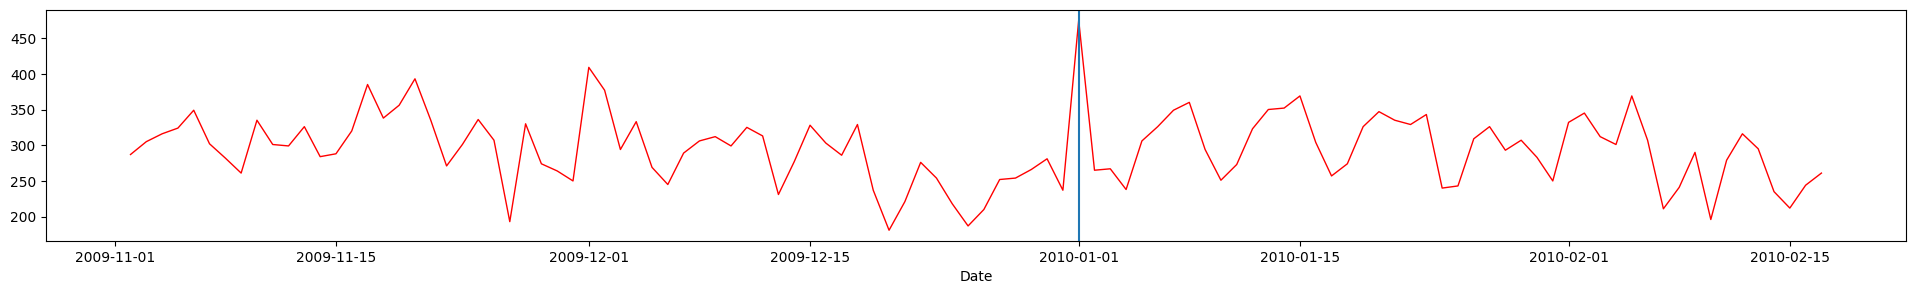

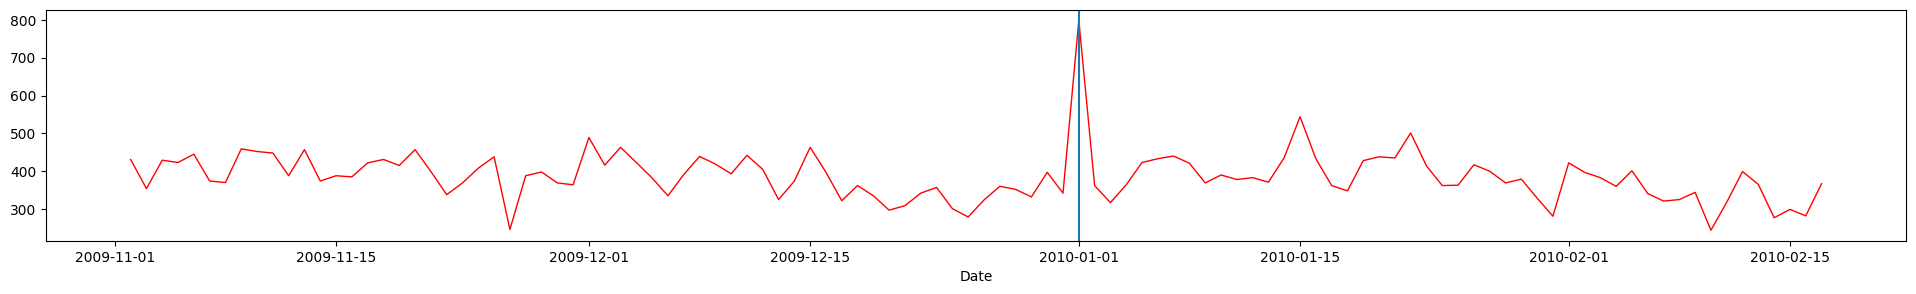

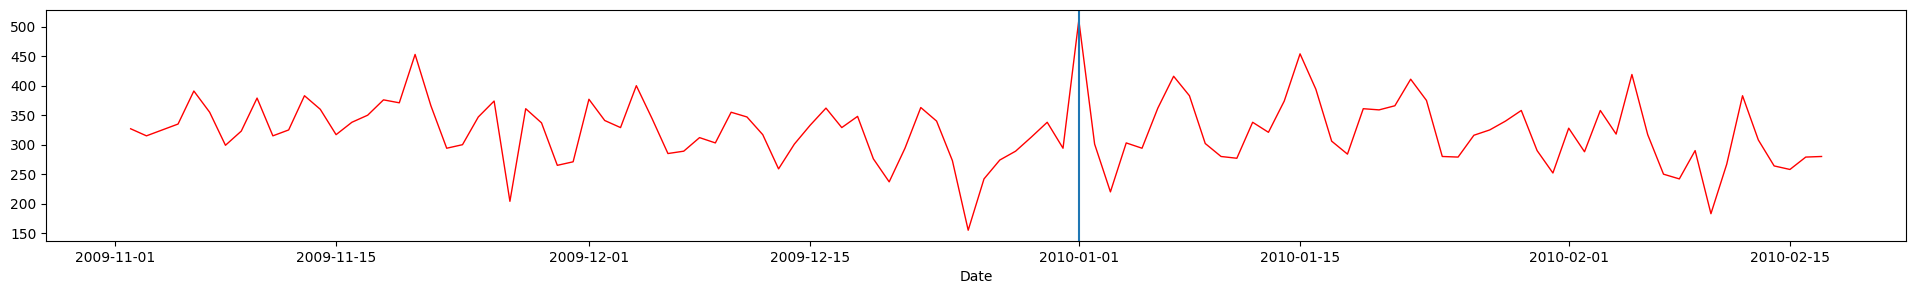

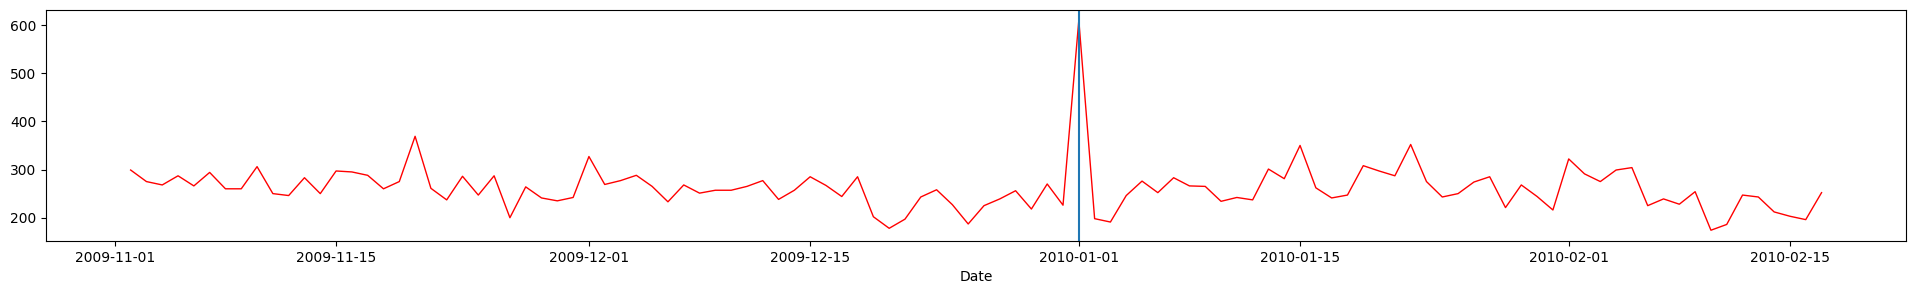

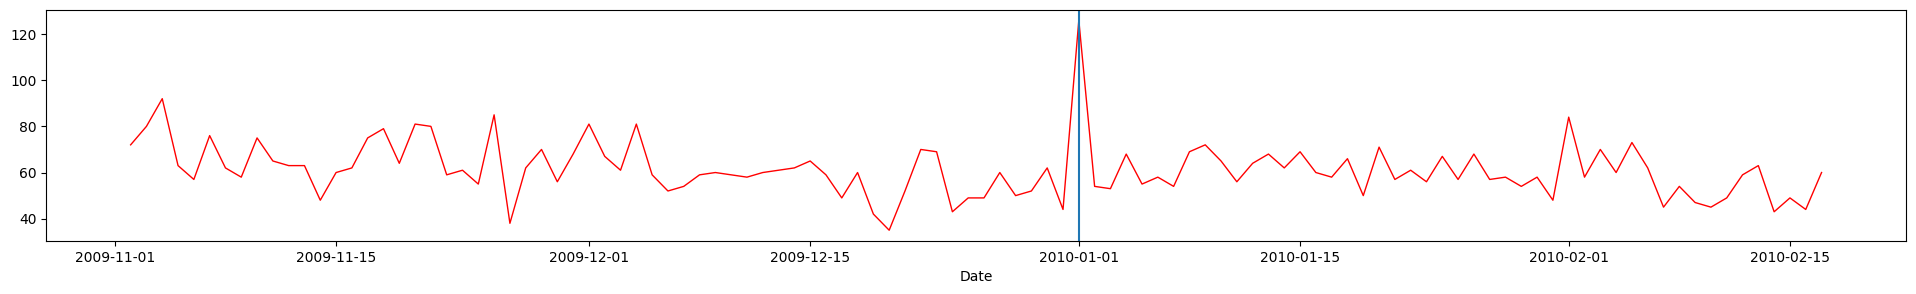

In [23]:
def plot_df(df, id, timestamp, graph_before, steps_ahead, plt_tmp=plt, unit='D'):
    true_y = df.loc[(df["unique_id"]==id) & (df["ds"]>=timestamp-pd.Timedelta(graph_before, unit=unit)) & (df["ds"]<timestamp+pd.Timedelta(steps_ahead, unit=unit)), "y"].to_numpy().flatten()
    plt_tmp.plot(df.loc[(df["unique_id"]==id) & (df["ds"]>=timestamp-pd.Timedelta(graph_before, unit=unit)) & (df["ds"]<timestamp+pd.Timedelta(steps_ahead, unit=unit)), "ds"].to_numpy().flatten(), true_y, label=f"True", linewidth=1, color='r')

id = 0
for id in range(5):
    plt.figure(figsize=(24,3))
    timestamp = pd.Timestamp("2010-01-01")
    graph_before = 30*2
    steps_ahead = 48
    plot_df(new_df, id, timestamp, graph_before, steps_ahead)
    plt.axvline(timestamp)
    # plt.ylabel(column_dict[id][0])
    plt.xlabel("Date")
    plt.show()